<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/FRS_%EC%9D%B8%EA%B3%B5%EC%A7%80%EC%A7%84%ED%8C%8C%EC%83%9D%EC%84%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iteration 1 완료
Iteration 2 완료
Iteration 3 완료
Iteration 4 완료
Iteration 5 완료
Iteration 6 완료
Iteration 7 완료
Iteration 8 완료
완료: /content/drive/MyDrive/FRS/artificial_eq_matched.csv


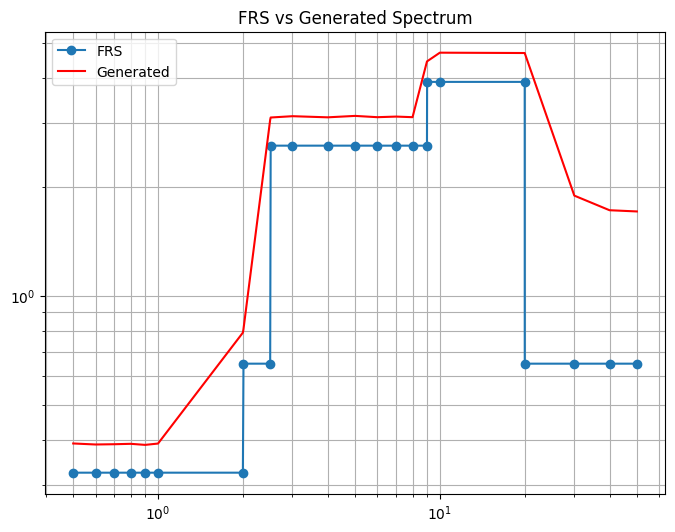

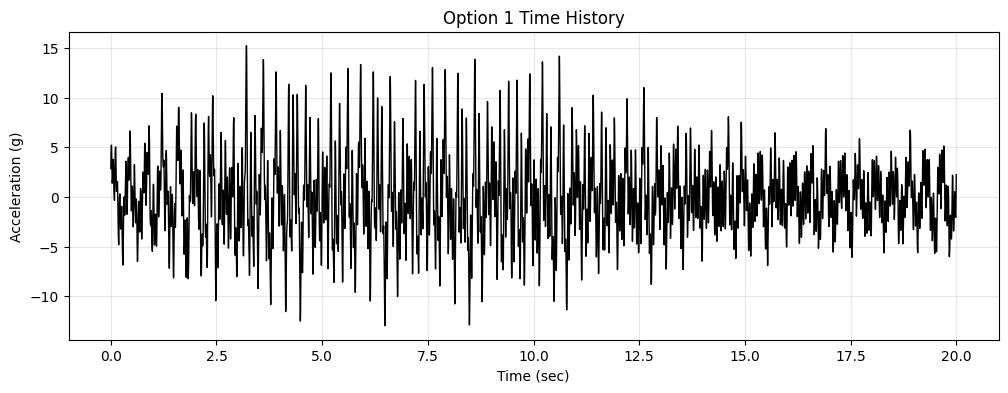

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 설정
# ==============================
FRS_PATH = '/content/drive/MyDrive/FRS/EW_FRS.csv'
OUTPUT_PATH = '/content/drive/MyDrive/FRS/artificial_eq_matched.csv'

TOTAL_TIME = 20.0
DT = 0.002
G = 9.81
ITERATIONS = 8   # 반복 횟수 (5~10 권장)

# ==============================
# FRS 로드
# ==============================
df = pd.read_csv(FRS_PATH)

freq = df.iloc[:,0].values
MARGIN = 1.3
Sa_target = df.iloc[:,1].values * MARGIN  # g

# ==============================
# 초기 파형 생성
# ==============================
t = np.arange(0, TOTAL_TIME, DT)
acc = np.zeros_like(t)

np.random.seed(1)
phi = np.random.uniform(0, 2*np.pi, len(freq))

for i in range(len(freq)):
    f = freq[i]
    acc += np.sin(2*np.pi*f*t + phi[i])

# Envelope
def envelope(t):
    return np.minimum(t/3,1.0) * np.exp(-np.maximum(t-10,0)/5)

acc *= envelope(t)

# ==============================
# 응답스펙트럼 함수
# ==============================
def response_spectrum(acc, dt, freq):
    zeta = 0.05
    Sa = []

    for f in freq:
        w = 2*np.pi*f
        k = w**2
        c = 2*zeta*w

        u=v=0
        umax=0

        for a in acc:
            u_dd = -c*v - k*u - a
            v += u_dd*dt
            u += v*dt
            umax = max(umax, abs(u))

        Sa.append(umax*w**2 / G)

    return np.array(Sa)

# ==============================
# Iterative Matching
# ==============================
for it in range(ITERATIONS):

    Sa_gen = response_spectrum(acc, DT, freq)

    ratio = Sa_target / (Sa_gen + 1e-6) * 1.2   #보수성 1.1 추가

    # 보정 (핵심: 부드럽게)
    correction = np.interp(
        np.fft.rfftfreq(len(t), DT),
        freq,
        ratio,
        left=1,
        right=1
    )

    fft_acc = np.fft.rfft(acc)
    fft_acc *= correction
    acc = np.fft.irfft(fft_acc, n=len(t))

    print(f"Iteration {it+1} 완료")

# ==============================
# 결과 저장
# ==============================
result = pd.DataFrame({
    'Time': t,
    'Acc(g)': acc
})

result.to_csv(OUTPUT_PATH, index=False)

print("완료:", OUTPUT_PATH)

# ==============================
# 결과 비교
# ==============================
Sa_final = response_spectrum(acc, DT, freq)

plt.figure(figsize=(8,6))
plt.plot(freq, Sa_target, 'o-', label='FRS')
plt.plot(freq, Sa_final, 'r-', label='Generated')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both')
plt.title("FRS vs Generated Spectrum")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, acc, 'k-', lw=1)
plt.xlabel('Time (sec)')
plt.ylabel('Acceleration (g)')
plt.title('Time History')
plt.grid(True, alpha=0.3)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iteration 1 완료 | min ratio = 0.570, max ratio = 4.285
Iteration 2 완료 | min ratio = 0.860, max ratio = 5.157
Iteration 3 완료 | min ratio = 0.952, max ratio = 5.712
Iteration 4 완료 | min ratio = 1.002, max ratio = 6.011
Iteration 5 완료 | min ratio = 1.024, max ratio = 6.144
Iteration 6 완료 | min ratio = 0.911, max ratio = 5.467
Iteration 7 완료 | min ratio = 0.983, max ratio = 5.899
Iteration 8 완료 | min ratio = 1.017, max ratio = 6.099
Iteration 9 완료 | min ratio = 1.030, max ratio = 6.180
Iteration 10 완료 | min ratio = 0.917, max ratio = 5.499
Iteration 11 완료 | min ratio = 0.986, max ratio = 5.916
Iteration 12 완료 | min ratio = 1.018, max ratio = 6.106
Iteration 13 완료 | min ratio = 1.031, max ratio = 6.182
Iteration 14 완료 | min ratio = 0.917, max ratio = 5.501
Iteration 15 완료 | min ratio = 0.988, max ratio = 5.926

완료: /content/drive/MyDrive/FRS/artificial_eq_matched_i

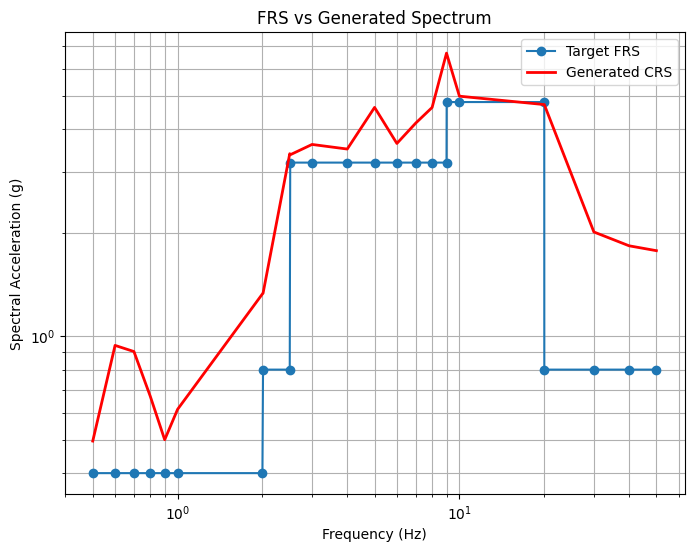

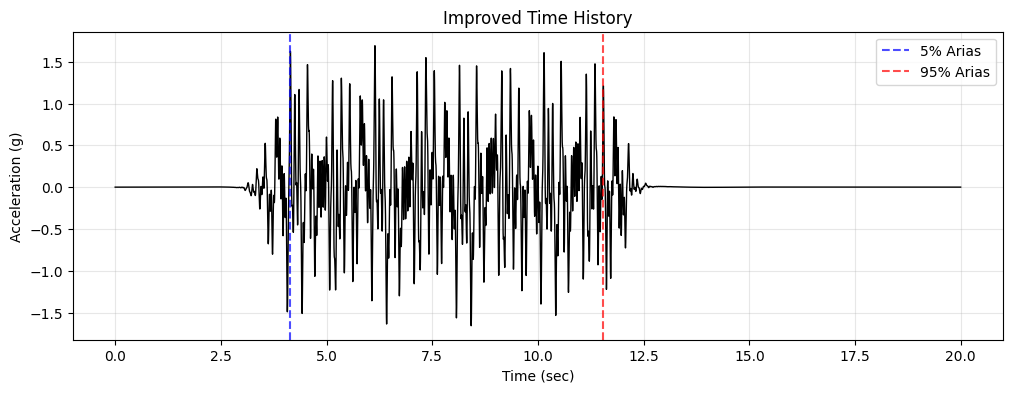

    Freq(Hz)  Target(g)  Generated(g)  Ratio(Gen/Target)
0       0.50        0.4      0.495762           1.239405
1       0.60        0.4      0.940784           2.351960
2       0.70        0.4      0.902894           2.257235
3       0.80        0.4      0.669140           1.672851
4       0.90        0.4      0.500165           1.250413
5       1.00        0.4      0.613136           1.532839
6       2.00        0.4      1.328209           3.320523
7       2.01        0.8      1.333322           1.666653
8       2.50        0.8      3.396428           4.245534
9       2.51        3.2      3.372094           1.053779
10      3.00        3.2      3.613493           1.129217
11      4.00        3.2      3.504052           1.095016
12      5.00        3.2      4.630837           1.447136
13      6.00        3.2      3.637858           1.136831
14      7.00        3.2      4.169533           1.302979
15      8.00        3.2      4.628560           1.446425
16      9.00        3.2      6.

In [37]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 설정
# ==============================
FRS_PATH = '/content/drive/MyDrive/FRS/EW_FRS.csv'
OUTPUT_PATH = '/content/drive/MyDrive/FRS/artificial_eq_matched_improved.csv'

TOTAL_TIME = 20.0
DT = 0.002
G = 9.81
ITERATIONS = 15

# 포괄 여유
MARGIN = 1.60

# 보정 계수 제한
CORR_MIN = 0.90
CORR_MAX = 1.30

# 재현성
np.random.seed(1)

# ==============================
# FRS 로드
# ==============================
df = pd.read_csv(FRS_PATH)
freq = df.iloc[:, 0].values.astype(float)
Sa_target = df.iloc[:, 1].values.astype(float) * MARGIN  # g

mask = (freq > 0.1) & (freq <= 50.0)
freq = freq[mask]
Sa_target = Sa_target[mask]

# ==============================
# 시간축
# ==============================
t = np.arange(0, TOTAL_TIME, DT)
n = len(t)

# ==============================
# Envelope 개선
# - 상승 / 강진 / 감쇠
# ==============================
def envelope(t):
    env = np.zeros_like(t)

    # 0∼4초 상승
    m1 = t < 4.0
    env[m1] = np.sin(0.5 * np.pi * t[m1] / 4.0) ** 2

    # 4∼12초 강진 지속
    m2 = (t >= 4.0) & (t < 12.0)
    env[m2] = 1.0

    # 12∼20초 감쇠
    m3 = t >= 12.0
    env[m3] = np.exp(-(t[m3] - 12.0) / 4.5)

    return env

env = envelope(t)

# ==============================
# Smoothing 함수
# ==============================
def smooth(x, window=9):
    if window <= 1:
        return x.copy()
    pad = window // 2
    xp = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(xp, kernel, mode='valid')

# ==============================
# Baseline correction
# ==============================
def baseline_correction(acc, dt):
    acc = acc - np.mean(acc)

    vel = np.cumsum(acc) * dt
    vel = vel - np.linspace(vel[0], vel[-1], len(vel))

    disp = np.cumsum(vel) * dt
    disp = disp - np.linspace(disp[0], disp[-1], len(disp))

    vel2 = np.gradient(disp, dt)
    acc2 = np.gradient(vel2, dt)

    return acc2 - np.mean(acc2)

# ==============================
# Band limitation
# - 너무 낮거나 높은 주파수 성분 억제
# ==============================
def band_limit(acc, dt, f_low=0.2, f_high=30.0):
    fft_acc = np.fft.rfft(acc)
    fft_freq = np.fft.rfftfreq(len(acc), dt)

    filt = np.ones_like(fft_freq)

    filt[fft_freq < f_low] = 0.0
    filt[fft_freq > f_high] = 0.0

    # 완만한 천이
    trans = 0.3

    low_mask = (fft_freq >= f_low) & (fft_freq < f_low + trans)
    high_mask = (fft_freq > f_high - trans) & (fft_freq <= f_high)

    if np.any(low_mask):
        filt[low_mask] *= (fft_freq[low_mask] - f_low) / trans
    if np.any(high_mask):
        filt[high_mask] *= (f_high - fft_freq[high_mask]) / trans

    fft_acc *= filt
    return np.fft.irfft(fft_acc, n=len(acc))

# ==============================
# 응답스펙트럼 함수
# - 원본 구조 유지
# - 입력 acc는 g 단위
# ==============================
def response_spectrum(acc, dt, freq):
    zeta = 0.05
    Sa = []

    for f in freq:
        w = 2*np.pi*f
        k = w**2
        c = 2*zeta*w

        u = 0.0
        v = 0.0
        umax = 0.0

        for a_g in acc:
            a = a_g * G
            u_dd = -c*v - k*u - a
            v += u_dd * dt
            u += v * dt
            umax = max(umax, abs(u))

        Sa.append(umax * w**2 / G)

    return np.array(Sa)

# ==============================
# Arias intensity 기반 strong motion duration
# ==============================
def strong_motion_duration(acc_g, dt):
    acc = acc_g * G
    Ia = np.cumsum(acc**2) * dt
    Ia /= (Ia[-1] + 1e-12)

    t5 = np.interp(0.05, Ia, t)
    t95 = np.interp(0.95, Ia, t)
    return t95 - t5, t5, t95

# ==============================
# 초기 파형 생성
# - 원본과 유사하되 목표 스펙트럼 형상 반영
# ==============================
acc = np.zeros_like(t)
phi = np.random.uniform(0, 2*np.pi, len(freq))

amp0 = Sa_target / (np.max(Sa_target) + 1e-12)

for i, f in enumerate(freq):
    acc += amp0[i] * np.sin(2*np.pi*f*t + phi[i])

acc *= env
acc = baseline_correction(acc, DT)
acc = band_limit(acc, DT)

# 초기 PGA 조정
target_pga = max(0.10, 0.22 * np.max(Sa_target))
acc *= target_pga / (np.max(np.abs(acc)) + 1e-12)

# ==============================
# Iterative Matching
# ==============================
for it in range(ITERATIONS):

    Sa_gen = response_spectrum(acc, DT, freq)

    # 원본 구조 유지
    ratio = Sa_target / (Sa_gen + 1e-6)

    # 보수성 확보
    ratio *= 1.10

    # 부드럽게 보정
    ratio = smooth(ratio, window=7)
    ratio = np.clip(ratio, CORR_MIN, CORR_MAX)

    correction = np.interp(
        np.fft.rfftfreq(len(t), DT),
        freq,
        ratio,
        left=1.0,
        right=1.0
    )

    correction = smooth(correction, window=11)
    correction = np.clip(correction, CORR_MIN, CORR_MAX)

    fft_acc = np.fft.rfft(acc)
    fft_acc *= correction
    acc = np.fft.irfft(fft_acc, n=len(t))

    # 시간영역 파형 개선용 후처리
    acc = baseline_correction(acc, DT)
    acc = band_limit(acc, DT, f_low=0.2, f_high=30.0)
    acc *= env

    # 매 반복마다 전체 스케일 약간 재조정
    Sa_chk = response_spectrum(acc, DT, freq)
    under_ratio = np.min(Sa_chk / (Sa_target + 1e-8))
    if under_ratio < 0.90:
        acc *= min(1.08 / under_ratio, 1.15)

    Sa_chk = response_spectrum(acc, DT, freq)
    ratio_chk = Sa_chk / (Sa_target + 1e-8)

    ######local correction step 추가
    # ==============================
    # 부족 대역만 국부 보강
    # ==============================
    fft_freq = np.fft.rfftfreq(len(t), DT)
    fft_acc_local = np.fft.rfft(acc)

    deficient_idx = np.where(ratio_chk < 1.02)[0]

    if len(deficient_idx) > 0:
        local_gain = np.ones_like(fft_freq)

        for idx in deficient_idx:
            f0 = freq[idx]
            deficit = 1.02 - ratio_chk[idx]

            # 대역폭: 저주파는 넓게, 고주파는 상대적으로 좁게
            bw = max(0.12 * f0, 0.20)

            bump = np.exp(-0.5 * ((fft_freq - f0) / bw) ** 2)

            # 부족한 만큼만 증폭
            amp = min(0.45, 0.85 * deficit)
            local_gain += amp * bump

        # 과도한 증폭 제한
        local_gain = np.clip(local_gain, 1.0, 1.45)

        fft_acc_local *= local_gain
        acc = np.fft.irfft(fft_acc_local, n=len(t))

        # 후처리
        acc = baseline_correction(acc, DT)
        acc = band_limit(acc, DT, f_low=0.2, f_high=30.0)
        acc *= env




    print(
        f"Iteration {it+1} 완료 | "
        f"min ratio = {ratio_chk.min():.3f}, "
        f"max ratio = {ratio_chk.max():.3f}"
    )

# ==============================
# 최종 정리
# ==============================
acc = baseline_correction(acc, DT)
acc = band_limit(acc, DT, f_low=0.2, f_high=30.0)
acc *= env

Sa_final = response_spectrum(acc, DT, freq)
ratio_final = Sa_final / (Sa_target + 1e-8)

pga = np.max(np.abs(acc))
dur, t5, t95 = strong_motion_duration(acc, DT)

# ==============================
# 저장
# ==============================
result = pd.DataFrame({
    'Time(sec)': t,
    'Acc(g)': acc
})
result.to_csv(OUTPUT_PATH, index=False)

print("\n완료:", OUTPUT_PATH)
print(f"PGA = {pga:.4f} g")
print(f"Strong motion duration (5∼95% Arias) = {dur:.3f} sec")

# ==============================
# 결과 비교
# ==============================
plt.figure(figsize=(8,6))
plt.plot(freq, Sa_target, 'o-', label='Target FRS')
plt.plot(freq, Sa_final, 'r-', lw=2, label='Generated CRS')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Acceleration (g)')
plt.legend()
plt.grid(True, which='both')
plt.title("FRS vs Generated Spectrum")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, acc, 'k-', lw=1)
plt.axvline(t5, color='b', ls='--', alpha=0.7, label='5% Arias')
plt.axvline(t95, color='r', ls='--', alpha=0.7, label='95% Arias')
plt.xlabel('Time (sec)')
plt.ylabel('Acceleration (g)')
plt.title('Improved Time History')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

summary = pd.DataFrame({
    'Freq(Hz)': freq,
    'Target(g)': Sa_target,
    'Generated(g)': Sa_final,
    'Ratio(Gen/Target)': ratio_final
})
print(summary)